<h2><font color="#004D7F" size=6>Módulo 3. Machine Learning</font></h2>

<h1><font color="#004D7F" size=5>1. Algoritmo Regresión KNN </font></h1>

<h1><font color="#004D7F" size=5>2. Taller de  Precio de Autos </font></h1>
<br>
<div style="text-align: right">
<font color="#004D7F" size=3>Seminario en Ciencia de Datos</font><br>

Para realizar un análisis con knn tenemos siempre de normalizar los datos, re-escalar todas las variables para que las distancias sean equiparables(homologable). Este proceso se suele llamar: estandarización de los datos.

Otro punto importante es que hay que eliminar los NA de los datos, pues afectan a los cálculos de distancia.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

# Cargar datos 
carros = pd.read_csv("carros.csv")

In [5]:
carros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   kms     39 non-null     int64
 1   precio  39 non-null     int64
dtypes: int64(2)
memory usage: 756.0 bytes


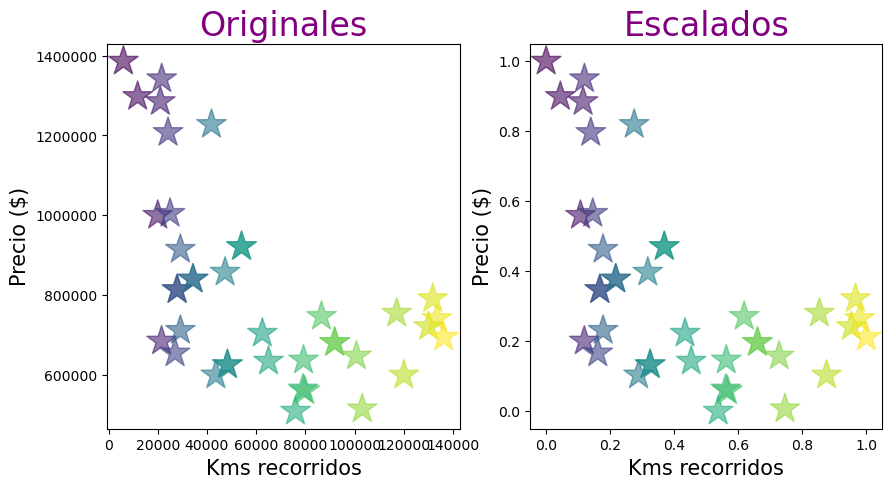

In [6]:
# Graficar datos crudos: kms vs precio
fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(1,2,1)

ax.scatter(carros["kms"], carros["precio"], marker="*", s=500, c=range(carros["kms"].size) , alpha=0.6 )

ax.set_title("Originales", size=24, color ="purple")
ax.set_ylabel("Precio ($)", size =15)
ax.set_xlabel("Kms recorridos", size =15)
ax.ticklabel_format(style="plain")


# Escalamiento

escala_kms = preprocessing.MinMaxScaler()

escala_precio = preprocessing.MinMaxScaler()

kms = escala_kms.fit_transform(carros["kms"].values.reshape(-1,1))

precio = escala_precio.fit_transform(carros["precio"].values.reshape(-1,1))


#Graficar los datos escalados

ax = fig.add_subplot(1,2,2)


ax.scatter(kms,precio, marker="*", s=500, c=range(kms.size) , alpha=0.6 )

ax.set_title("Escalados", size=24, color ="purple")
ax.set_ylabel("Precio ($)", size =15)
ax.set_xlabel("Kms recorridos", size =15)
ax.ticklabel_format(style="plain")

plt.show()

<br><br>
# Creación de Modelo KNN (regresión)

## K = 3

In [9]:
from sklearn.neighbors import KNeighborsRegressor

In [10]:
# Crear un modelo de regresion KNN con 3 vecinos cercanos
knn = KNeighborsRegressor(n_neighbors=3)

In [11]:
# Entrenar el modelo
knn.fit(kms,precio)


KNeighborsRegressor(n_neighbors=3)

In [12]:
# Escalar el valor de 20,000 kilometros
kms_instancia = escala_kms.transform([[20000]])


In [13]:
# Utiliza el modelo KNN para predecir el precio del automovil
precio_instancia = knn.predict(kms_instancia)

In [14]:
precio_instancia

array([[0.54817298]])

In [15]:
# Invierte la transformacion del escalador para obtner el precio del vehiculo en su escala original de enteros
precio_real = escala_precio.inverse_transform(precio_instancia)

In [16]:
# [0][0] selecionando el elemento de la primera fila del array
precio_formateado = round(precio_real[0][0], 2)
precio_formateado

990048.0

In [17]:
# Le damos formato al precio para mostrarlo
print(f"El precio estimado es: ${precio_formateado:,.2f}")

El precio estimado es: $990,048.00


<br><br>
# Precios de Carros de 0 a 140,000 km

In [35]:
# Múltiples regresiones de los valores dentro del rango
kms_instancia = escala_kms.transform(np.arange(140000).reshape(-1,1))

In [37]:
precio_instancias = knn.predict(kms_instancia)

In [39]:
precio_instancias

array([[0.81955816],
       [0.81955816],
       [0.81955816],
       ...,
       [0.26589732],
       [0.26589732],
       [0.26589732]])

In [41]:
#Invertir la transformacion del escalador para obtener los precios en su escala original
todas = escala_precio.inverse_transform(precio_instancias)

In [43]:
# Reestructurar el array para que este en una dimencion
todas = todas.reshape(1,-1)
todas

array([[1227846.        , 1227846.        , 1227846.        , ...,
         742707.33333333,  742707.33333333,  742707.33333333]])

In [45]:
# Crear una grafica
fig = plt.figure(figsize=(6,4))

<Figure size 600x400 with 0 Axes>

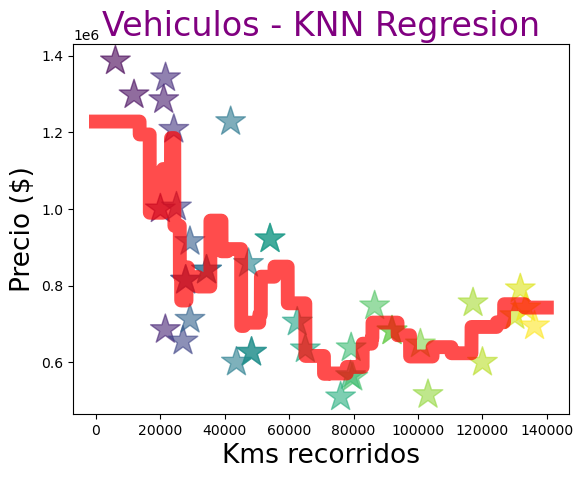

In [49]:
plt.plot(np.arange(140000),todas.reshape(1,-1)[0], linewidth=10, color="red", alpha=0.7 )


plt.scatter(carros["kms"], carros["precio"], marker="*", s=500, c=range(carros["kms"].size), alpha=0.6)

plt.title("Vehiculos - KNN Regresion", size=24, color="purple")
plt.ylabel("Precio ($)", size=19)
plt.xlabel("Kms recorridos", size=19)
plt.show()